In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("../dataset/job_market_analysis.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2873, 19)


,slug,company_name,title,description,remote,url,tags,job_types,location,created_at,posted_date,posted_year,posted_month,remote_status,job_category,experience_level,city,skills,skill_count
0,software-engineer-price-comparison-portal-berl...,Preiswecker,Software Engineer,Preiswecker is a price comparison portal in Ge...,False,https://www.preiswecker.com/,Software Engineering | E-Commerce,Full-time,Berlin,2026-08-12 06:40:00,2026-08-12,2026,August,On-site,Software & IT,Mid Level / Other,Berlin,NaN,0
1,senior-product-manager-356253,Verve,Senior Product Manager,Who We Are Verve has created a more efficient ...,False,https://www.arbeitnow.com/jobs/companies/verve...,Product Management,NaN,Unknown,2026-10-01 05:55:15,2026-10-01,2026,October,On-site,Other,Senior,Unknown,NaN,0
2,working-student-launch-operations-parsdorf-bav...,isaraerospace,Working Student Launch Operations (m/f/d),Mission Brief As Working Student Launch Operat...,False,https://www.arbeitnow.com/jobs/companies/isara...,Mission & Launch Operations,NaN,"Parsdorf, Bavaria",2026-10-01 05:55:11,2026-10-01,2026,October,On-site,Other,Mid Level / Other,Parsdorf,NaN,0
3,senior-mechanical-engineer-parsdorf-bavaria-38...,isaraerospace,Senior Mechanical Engineer (f/m/d),Mission Brief We deliver the half of the rocke...,False,https://www.arbeitnow.com/jobs/companies/isara...,Ground Systems,NaN,"Parsdorf, Bavaria",2026-10-01 05:55:11,2026-10-01,2026,October,On-site,Software & IT,Senior,Parsdorf,NaN,0
4,mes-process-and-system-engineer-parsdorf-bavar...,isaraerospace,MES Process and System Engineer (m/f/d),Mission Brief&nbsp; Help build the digital man...,False,https://www.arbeitnow.com/jobs/companies/isara...,Production | Operations & Quality,NaN,"Parsdorf, Bavaria",2026-10-01 05:55:11,2026-10-01,2026,October,On-site,Software & IT,Mid Level / Other,Parsdorf,NaN,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2873 entries, 0 to 2872
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   slug              2873 non-null   str  
 1   company_name      2873 non-null   str  
 2   title             2873 non-null   str  
 3   description       2873 non-null   str  
 4   remote            2873 non-null   bool 
 5   url               2873 non-null   str  
 6   tags              2625 non-null   str  
 7   job_types         2005 non-null   str  
 8   location          2872 non-null   str  
 9   created_at        2873 non-null   str  
 10  posted_date       2873 non-null   str  
 11  posted_year       2873 non-null   int64
 12  posted_month      2873 non-null   str  
 13  remote_status     2873 non-null   str  
 14  job_category      2873 non-null   str  
 15  experience_level  2873 non-null   str  
 16  city              2872 non-null   str  
 17  skills            928 non-null    str  
 18 

In [6]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
slug                   0
company_name           0
title                  0
description            0
remote                 0
url                    0
tags                 248
job_types            868
location               1
created_at             0
posted_date            0
posted_year            0
posted_month           0
remote_status          0
job_category           0
experience_level       0
city                   1
skills              1945
skill_count            0
dtype: int64

Duplicate rows: 0


In [7]:
# Check whether skills were extracted from job descriptions
df.loc[
    df["skills"].isna() | df["skills"].eq(""),
    ["title", "tags", "description", "skills"]
].head(10)

,title,tags,description,skills
0,Software Engineer,Software Engineering | E-Commerce,Preiswecker is a price comparison portal in Ge...,NaN
1,Senior Product Manager,Product Management,Who We Are Verve has created a more efficient ...,NaN
2,Working Student Launch Operations (m/f/d),Mission & Launch Operations,Mission Brief As Working Student Launch Operat...,NaN
3,Senior Mechanical Engineer (f/m/d),Ground Systems,Mission Brief We deliver the half of the rocke...,NaN
4,MES Process and System Engineer (m/f/d),Production | Operations & Quality,Mission Brief&nbsp; Help build the digital man...,NaN
5,Executive Assistant to the Chief of Staff (m/f/d),CEO Office,Mission Brief&nbsp; As Executive Assistant to ...,NaN
6,Director Value Stream (m/f/d),Production | Operations & Quality,Mission Brief&nbsp; The Director Value Stream ...,NaN
8,Chief Quality Inspector (m/f/d),Production | Operations & Quality,Mission Brief&nbsp; The Chief Quality Inspecto...,NaN
9,Strategic Account Executive (DACH),Enterprise Sales,Our Strategic Account Executives target and cl...,NaN
12,"Legal Counsel, Fintech - New Payments - Luxemb...",Governance | Legal & Compliance,Please note that this opportunity requires rel...,NaN


In [9]:
skills = [
    "python",
    "sql",
    "excel",
    "power bi",
    "tableau",
    "r",
    "statistics",
    "machine learning",
    "pandas",
    "numpy",
    "aws",
    "azure",
    "gcp",
    "spark",
    "java",
    "javascript",
    "postgresql",
    "mysql",
    "data analysis",
    "data visualization",
    "scikit-learn",
    "tensorflow",
    "pytorch",
    "matplotlib",
    "seaborn",
    "looker",
    "dbt",
    "snowflake",
    "bigquery",
    "etl"
]

print("Number of skill keywords:", len(skills))

Number of skill keywords: 30


In [10]:
print("Skills list:")
print(skills)

print("\nNumber of skill keywords:", len(skills))

Skills list:
['python', 'sql', 'excel', 'power bi', 'tableau', 'r', 'statistics', 'machine learning', 'pandas', 'numpy', 'aws', 'azure', 'gcp', 'spark', 'java', 'javascript', 'postgresql', 'mysql', 'data analysis', 'data visualization', 'scikit-learn', 'tensorflow', 'pytorch', 'matplotlib', 'seaborn', 'looker', 'dbt', 'snowflake', 'bigquery', 'etl']

Number of skill keywords: 30


In [11]:
import re
import pandas as pd

def find_skills(text):
    if pd.isna(text):
        return []

    text = str(text).lower()
    found_skills = []

    for skill in skills:
        pattern = r"(?<!\w)" + re.escape(skill.lower()) + r"(?!\w)"

        if re.search(pattern, text):
            found_skills.append(skill)

    return found_skills


df["skills"] = df["description"].apply(find_skills)

df["skill_count"] = df["skills"].apply(len)

df[["title", "skills", "skill_count"]].head(10)

,title,skills,skill_count
0,Software Engineer,[],0
1,Senior Product Manager,[data analysis],1
2,Working Student Launch Operations (m/f/d),[],0
3,Senior Mechanical Engineer (f/m/d),[r],1
4,MES Process and System Engineer (m/f/d),[],0
5,Executive Assistant to the Chief of Staff (m/f/d),[],0
6,Director Value Stream (m/f/d),[],0
7,Cybersecurity Engineer (m/f/d),[python],1
8,Chief Quality Inspector (m/f/d),[],0
9,Strategic Account Executive (DACH),[],0


In [12]:
print("Total job records:", len(df))
print("Jobs with at least one detected skill:", (df["skill_count"] > 0).sum())
print("Jobs without detected skills:", (df["skill_count"] == 0).sum())

skill_counts = (
    df["skills"]
    .explode()
    .dropna()
    .value_counts()
)

print("\nTop 15 detected skills:")
print(skill_counts.head(15))

Total job records: 2873
Jobs with at least one detected skill: 1078
Jobs without detected skills: 1795

Top 15 detected skills:
skills
python              398
excel               262
sql                 204
r                   198
aws                 195
azure               145
java                130
machine learning    110
javascript           86
postgresql           73
gcp                  60
spark                48
etl                  40
dbt                  37
data analysis        34
Name: count, dtype: int64


In [13]:
# Remove the ambiguous single-letter skill "r"
skills = [skill for skill in skills if skill != "r"]

# Re-extract skills
df["skills"] = df["description"].apply(find_skills)

# Recalculate skill count
df["skill_count"] = df["skills"].apply(len)

# Calculate skill frequency
skill_counts = (
    df["skills"]
    .explode()
    .dropna()
    .value_counts()
)

print("Total job records:", len(df))
print("Jobs with detected skills:", (df["skill_count"] > 0).sum())
print("Jobs without detected skills:", (df["skill_count"] == 0).sum())

print("\nTop 15 detected skills:")
print(skill_counts.head(15))

Total job records: 2873
Jobs with detected skills: 974
Jobs without detected skills: 1899

Top 15 detected skills:
skills
python              398
excel               262
sql                 204
aws                 195
azure               145
java                130
machine learning    110
javascript           86
postgresql           73
gcp                  60
spark                48
etl                  40
dbt                  37
data analysis        34
power bi             33
Name: count, dtype: int64


In [14]:
df.to_csv(
    "../dataset/job_market_analysis.csv",
    index=False
)

print("Analytical dataset saved successfully!")
print("Rows and columns:", df.shape)

Analytical dataset saved successfully!
Rows and columns: (2873, 19)


In [15]:
import os
import pandas as pd

file_path = "../dataset/job_market_analysis.csv"

print("File exists:", os.path.exists(file_path))

check_df = pd.read_csv(file_path)

print("Saved dataset shape:", check_df.shape)
print("Duplicate rows:", check_df.duplicated().sum())

print("\nRequired columns:")
print(
    check_df[
        ["title", "company_name", "city", "job_category",
         "experience_level", "skills", "skill_count"]
    ].head()
)

File exists: True
Saved dataset shape: (2873, 19)
Duplicate rows: 0

Required columns:
                                       title   company_name      city  \
0                          Software Engineer    Preiswecker    Berlin   
1                     Senior Product Manager          Verve   Unknown   
2  Working Student Launch Operations (m/f/d)  isaraerospace  Parsdorf   
3         Senior Mechanical Engineer (f/m/d)  isaraerospace  Parsdorf   
4    MES Process and System Engineer (m/f/d)  isaraerospace  Parsdorf   

    job_category   experience_level             skills  skill_count  
0  Software & IT  Mid Level / Other                 []            0  
1          Other             Senior  ['data analysis']            1  
2          Other  Mid Level / Other                 []            0  
3  Software & IT             Senior                 []            0  
4  Software & IT  Mid Level / Other                 []            0  


## Exploratory Data Analysis (EDA)

The objective of this analysis is to understand job-market patterns by examining job categories, experience requirements, locations, remote opportunities, hiring companies, and in-demand skills.

Job counts by category:
job_category
Other                1678
Software & IT         635
Sales & Marketing     279
Data & Analytics      175
HR                     58
Finance                48
Name: count, dtype: int64


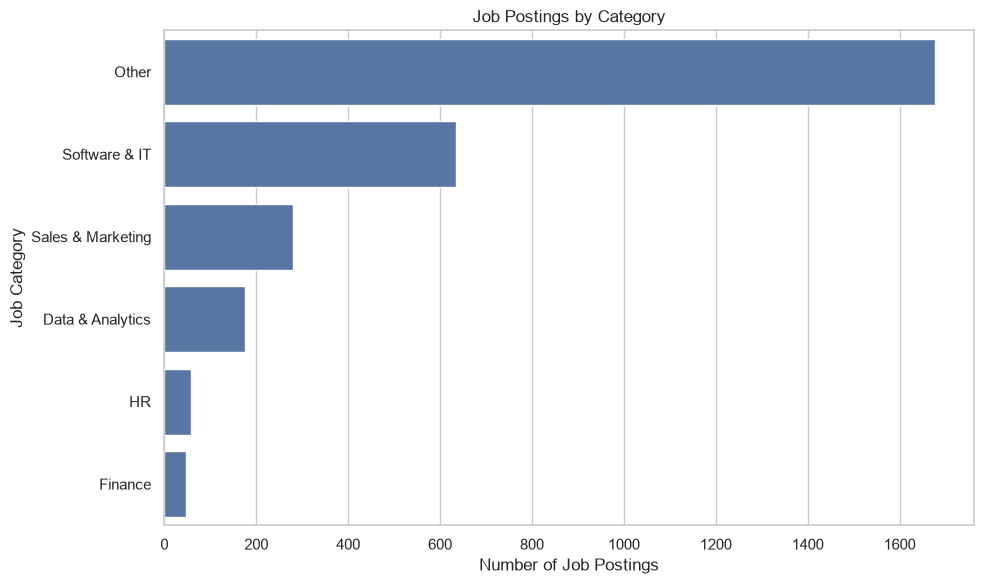

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

category_counts = df["job_category"].value_counts()

print("Job counts by category:")
print(category_counts)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=category_counts.values,
    y=category_counts.index
)

plt.title("Job Postings by Category")
plt.xlabel("Number of Job Postings")
plt.ylabel("Job Category")
plt.tight_layout()
plt.show()

Job postings by experience level:
experience_level
Mid Level / Other    1578
Senior                683
Lead / Manager        492
Entry Level           120
Name: count, dtype: int64


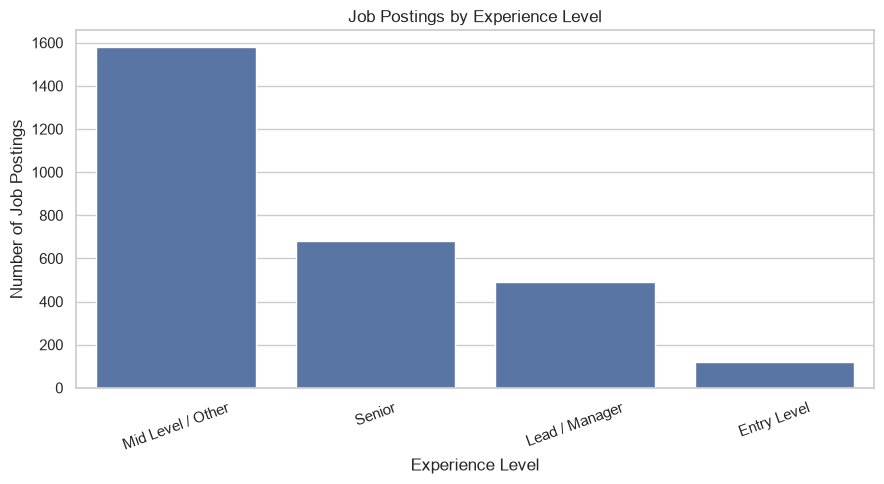

In [19]:
experience_counts = df["experience_level"].value_counts()

print("Job postings by experience level:")
print(experience_counts)

plt.figure(figsize=(9, 5))
sns.barplot(
    x=experience_counts.index,
    y=experience_counts.values
)

plt.title("Job Postings by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Remote work distribution:
remote_status
On-site    2662
Remote      211
Name: count, dtype: int64


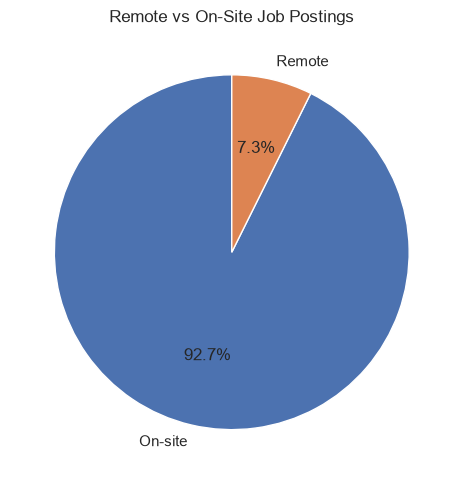

In [20]:
remote_counts = df["remote_status"].value_counts()

print("Remote work distribution:")
print(remote_counts)

plt.figure(figsize=(7, 5))
plt.pie(
    remote_counts.values,
    labels=remote_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Remote vs On-Site Job Postings")
plt.tight_layout()
plt.show()

Top 15 cities by job postings:
city
Berlin               584
Munich               265
Hamburg              167
München              120
London                72
Paris                 53
Köln                  50
Cologne               48
Remote                47
Stuttgart             45
Frankfurt am Main     45
Germany               41
Düsseldorf            39
Zürich                25
Homeoffice            23
Name: count, dtype: int64


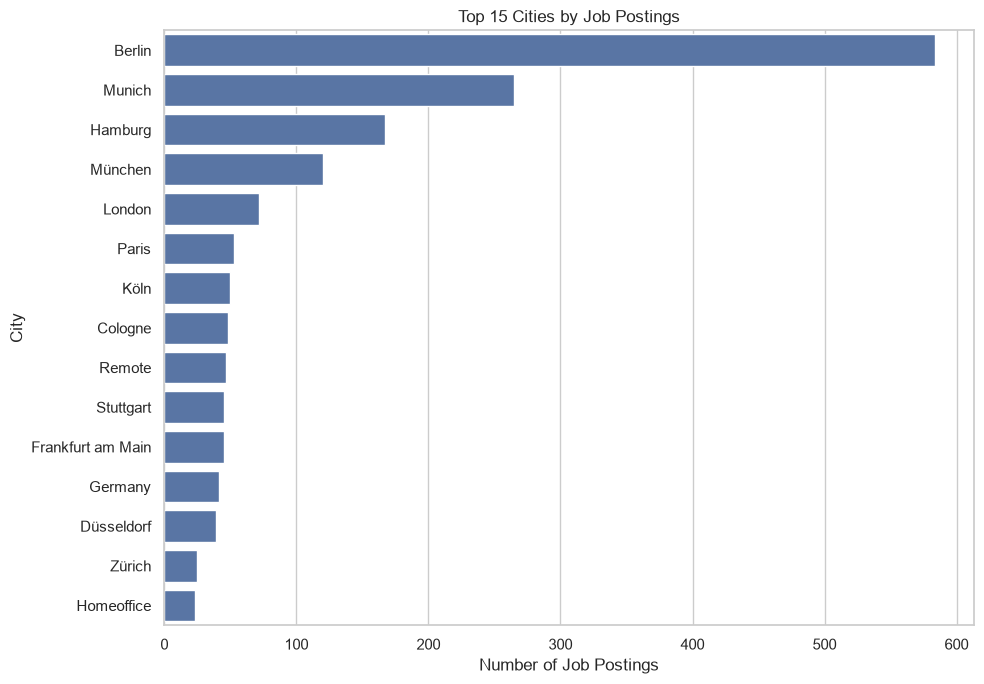

In [21]:
# Top 15 cities by job postings
city_counts = (
    df.loc[df["city"].notna() & (df["city"] != "Unknown"), "city"]
    .value_counts()
    .head(15)
)

print("Top 15 cities by job postings:")
print(city_counts)

plt.figure(figsize=(10, 7))

sns.barplot(
    x=city_counts.values,
    y=city_counts.index
)

plt.title("Top 15 Cities by Job Postings")
plt.xlabel("Number of Job Postings")
plt.ylabel("City")
plt.tight_layout()
plt.show()

Top 15 companies by job postings:
company_name
Taxtalente.de                           56
Init Ag                                 45
MY Humancapital GmbH                    43
Teampicnic                              29
Skalbach GmbH                           28
Collaboration Betters The World GmbH    22
PRECIA MOLEN                            21
Jobgether                               19
UNAFERM                                 18
Enpal                                   17
LILT (Production)                       16
celonis                                 16
Sunday Natural                          16
hellofresh                              15
Hubvisory                               15
Name: count, dtype: int64


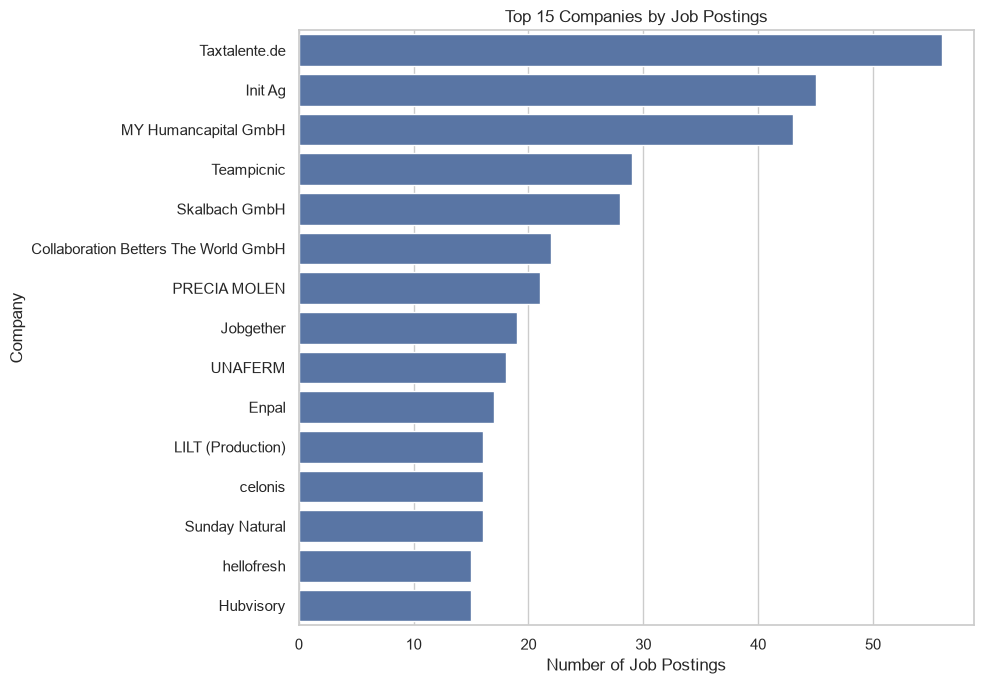

In [22]:
company_counts = (
    df["company_name"]
    .dropna()
    .value_counts()
    .head(15)
)

print("Top 15 companies by job postings:")
print(company_counts)

plt.figure(figsize=(10, 7))

sns.barplot(
    x=company_counts.values,
    y=company_counts.index
)

plt.title("Top 15 Companies by Job Postings")
plt.xlabel("Number of Job Postings")
plt.ylabel("Company")
plt.tight_layout()
plt.show()

Earliest posting date: 2026-08-12 00:00:00+00:00
Latest posting date: 2026-10-01 00:00:00+00:00
Missing posting dates: 0

Monthly job postings:
month
2026-08       1
2026-09    2710
2026-10     162
dtype: int64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2084\4225687673.py:21: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .assign(month=lambda x: x["posted_date"].dt.to_period("M").astype(str))


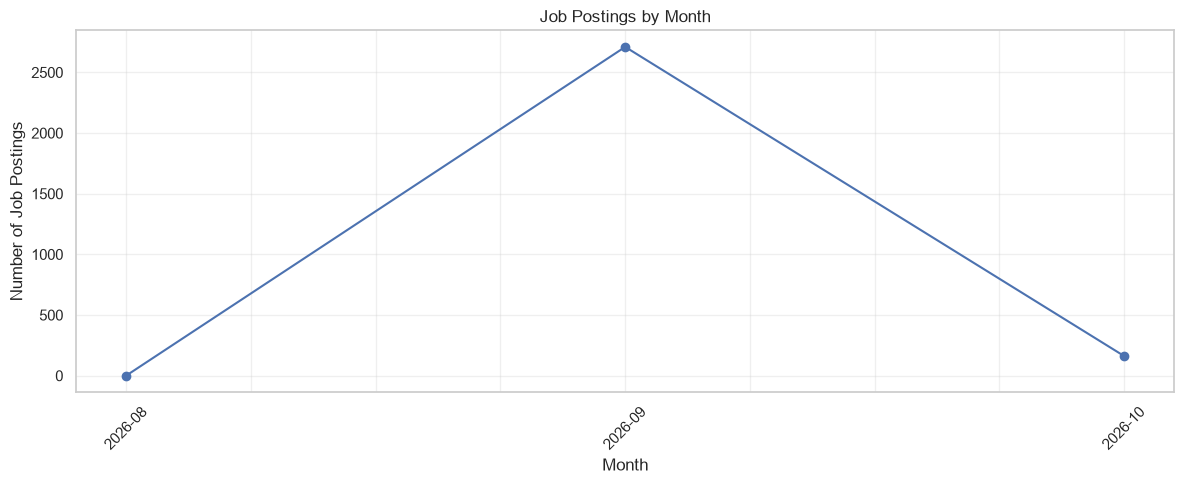

In [23]:

# Day 4: Job Posting Date Analysis

import pandas as pd
import matplotlib.pyplot as plt

# Convert posting date to datetime
df["posted_date"] = pd.to_datetime(
    df["posted_date"],
    errors="coerce",
    utc=True
)

# Check date coverage
print("Earliest posting date:", df["posted_date"].min())
print("Latest posting date:", df["posted_date"].max())
print("Missing posting dates:", df["posted_date"].isna().sum())

# Create monthly posting counts
monthly_jobs = (
    df.dropna(subset=["posted_date"])
      .assign(month=lambda x: x["posted_date"].dt.to_period("M").astype(str))
      .groupby("month")
      .size()
      .sort_index()
)

print("\nMonthly job postings:")
print(monthly_jobs)

# Visualize monthly job postings
plt.figure(figsize=(12, 5))
monthly_jobs.plot(kind="line", marker="o")

plt.title("Job Postings by Month")
plt.xlabel("Month")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



## Key Findings from Exploratory Data Analysis

1. **Job categories:** Software & IT accounted for 635 postings, while Data & Analytics accounted for 175 postings.

2. **Experience requirements:** Mid Level / Other was the largest experience group, with 1,578 postings. Senior roles accounted for 683 postings.

3. **Work arrangements:** The dataset contained 2,662 on-site postings and 211 remote postings.

4. **Geographic distribution:** Berlin was the leading city in the collected dataset, followed by Munich and Hamburg.

5. **Hiring companies:** TaxTalente.de had the highest number of postings among the companies analyzed.

6. **Posting trends:** [Describe the monthly pattern after reviewing the chart.]


7. **Posting trends:** The dataset contains 2,710 postings dated September 2026. October contains 162 postings through October 1, while August contains one posting. These counts reflect the dataset's collection and date coverage, not a complete measure of market-wide demand.


In [26]:

# Final Day 4 validation

print("Dataset shape:", df.shape)

# Check duplicates using columns that contain hashable values
duplicate_check = df.drop(columns=["skills"], errors="ignore")

print("Duplicate rows (excluding skills list):",
      duplicate_check.duplicated().sum())

print("Missing posting dates:", df["posted_date"].isna().sum())

print("\nAvailable EDA columns:")
print([
    "job_category",
    "experience_level",
    "remote_status",
    "city",
    "company_name",
    "posted_date"
])


Dataset shape: (2873, 19)
Duplicate rows (excluding skills list): 0
Missing posting dates: 0

Available EDA columns:
['job_category', 'experience_level', 'remote_status', 'city', 'company_name', 'posted_date']
